# Assignment 4 — Geospatial Mapping
Executed, checksum-gated offline analysis of genuine USDA-NRCS SSURGO data.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
repo=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
out=repo/'data/assignment-04/output'
q=json.loads((out/'spatial_quality_summary.json').read_text())
print('Offline:',q['offline'],'Network requests:',q['network_requests'])
print('Parsed:',q['parsed_polygon_features'],'Clipped:',q['clipped_polygon_features'],'Map units:',q['unique_map_units'])

Offline: True Network requests: 0
Parsed: 145 Clipped: 92 Map units: 22


## Field-level soil summary
`aws025wta` is available water storage from 0–25 cm, weighted across map-unit components, in centimeters of water. Missing values remain missing.

In [2]:
fields=pd.read_csv(out/'tables/field_soil_summary.csv')
display(fields.round(3))
print(fields['area_weighted_aws025wta'].describe())

,field_id,field_area_m2,covered_area_m2,coverage_percent,uncovered_percent,valued_coverage_percent,map_unit_count,area_weighted_aws025wta
0,451623001001160,17125.697,17125.697,100.0,0.0,100.0,2.0,2.044
1,451623001001187,11898.376,11898.376,100.0,0.0,100.0,1.0,3.500
2,451623001001196,70855.949,70855.949,100.0,0.0,100.0,2.0,3.496
3,451623001001204,13380.970,13380.970,100.0,0.0,100.0,2.0,3.498
4,451623001001218,25033.528,25033.528,100.0,0.0,100.0,1.0,2.950
5,451623001001219,18390.542,18390.542,100.0,0.0,100.0,3.0,2.953
6,451623001001224,17992.909,17992.909,100.0,0.0,100.0,1.0,2.950
7,451623001001231,16194.722,16194.722,100.0,0.0,100.0,2.0,2.985
8,451623001001238,10664.248,10664.248,100.0,0.0,100.0,2.0,3.008
9,451623001001243,23181.746,23181.746,100.0,0.0,100.0,4.0,3.413


count    25.000000
mean      3.114141
std       0.315615
min       2.043709
25%       2.954276
50%       3.055397
75%       3.413452
max       3.500000
Name: area_weighted_aws025wta, dtype: float64


## Final cartographic panel

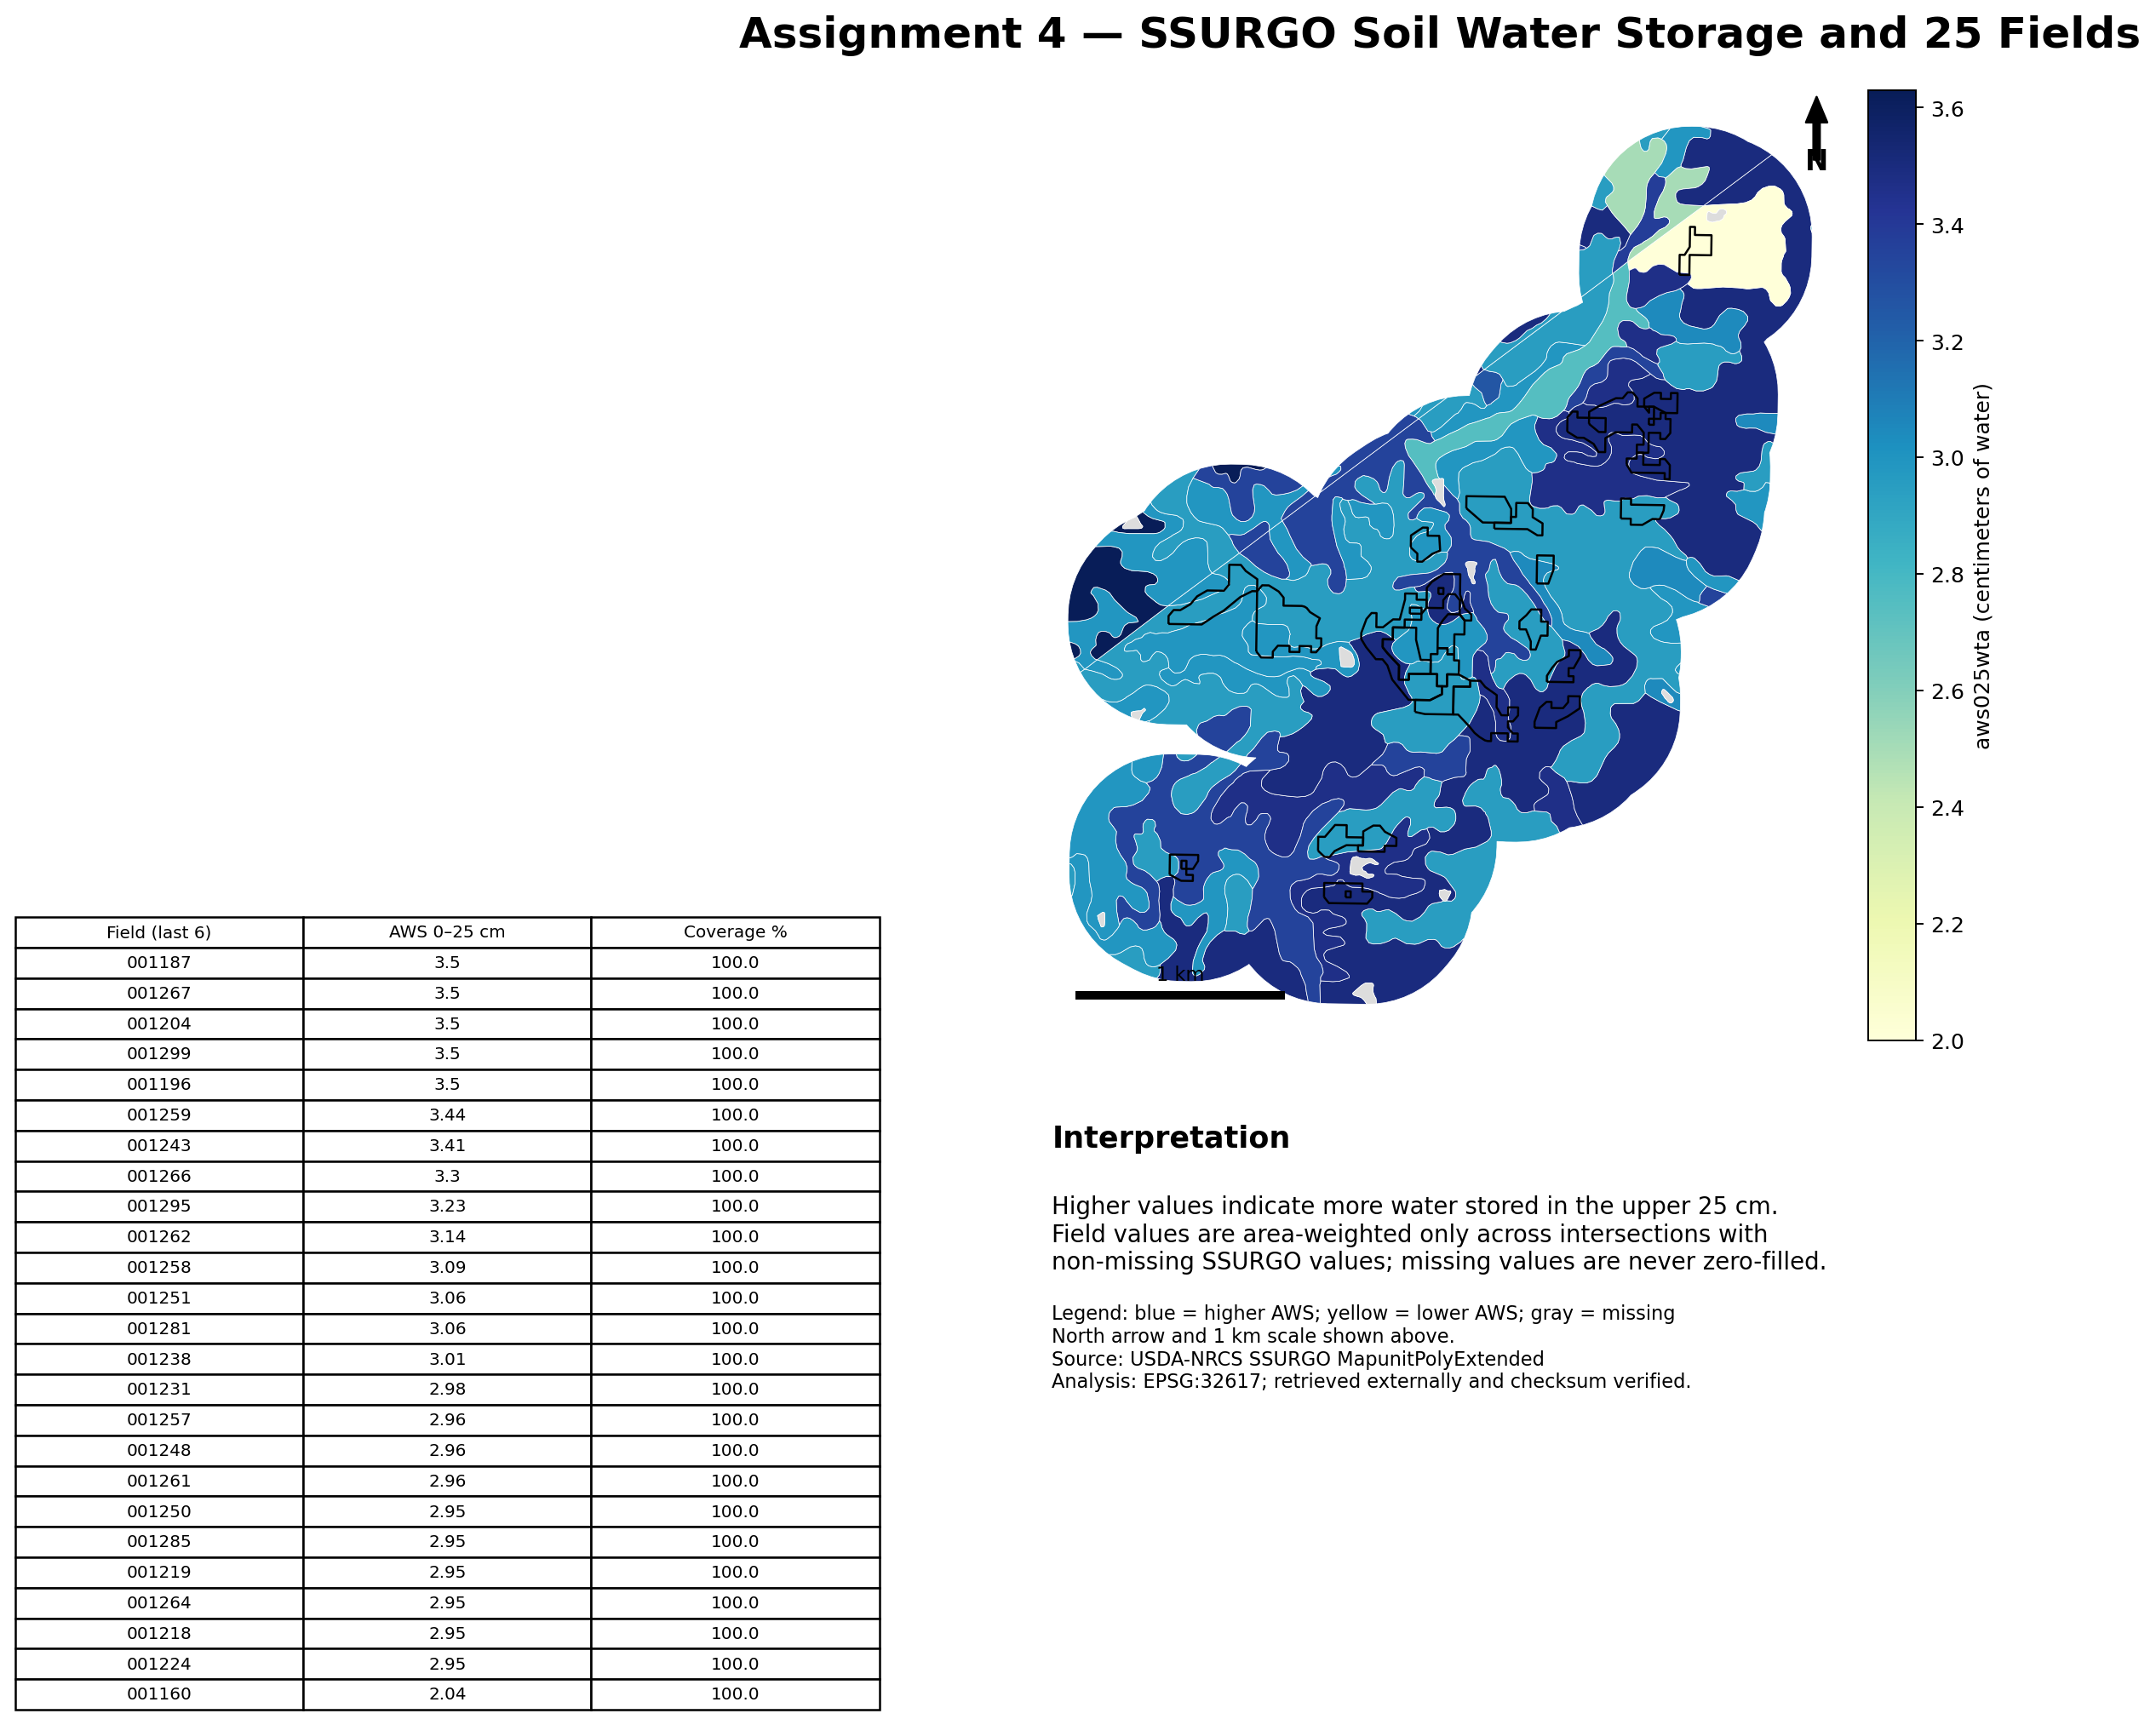

In [3]:
display(Image(filename=out/'maps/04_final_assignment_panel.png',width=1000))

## Spatial quality
The 500 m buffer was regenerated in EPSG:32617 and compared with the independently supplied external reference.

In [4]:
display(pd.Series(q).to_frame('value'))

,value
generated_utc,2026-07-28T19:29:51.360268+00:00
offline,True
network_requests,0
source_checksums,{'ssurgo_mapunit_response.gml': 'f7b9e32fb7f57...
source_byte_size,794318
schema_columns,"[gml_id, lowerCorner, upperCorner, areasymbol,..."
field_count,25
field_geometry_repairs,3
parsed_polygon_features,145
clipped_polygon_features,92
